<a href="https://colab.research.google.com/github/HydraMi/Aplicadas/blob/main/Grupo5_Entrega1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://www.icesi.edu.co/wp-content/uploads/2024/10/ICESI_logo_prin_descriptor_RGB_NEGATIVO_0924-768x395.png  width="300" height="200" align="center">

#**<big><big>Matemáticas Aplicadas II</big></big><br><small>Depto. Matemáticas & Estadística / Facultad de Ingeniería</small><br><small>_*Entrega 1*_ (Teoría de operadores integrales). </small>**

A continuación se le pide contestar o resolver por grupo las siguientes preguntas, utilizando una copia del presente cuaderno para consignar todas sus respuestas con el formato requerido.

**Usted debe leer y trabajar en los problemas del cuaderno y traer preguntas para la sesión del martes 8 de febrero.**

La entrega final es el día **viernes 14 de febrero** y dos **grupos** estarán encargados de socializar sus resultados y avances el día **miércoles 12 de febrero**.

**<u>Preguntas</u>**

A continuación encuentra separadas por celda cada pregunta, así usted solo debe continuar escribiendo en la celda para dar cada respuesta. No olvide que todas sus respuestas deben ir acompañadas de al menos un argumento geométrico o numérico y uno algebráico o en lenguaje natural.


1. (20 ptos) *Aproximación de integrales.*

  Tal como empezamos a discutir en clase hay diferentes aproximaciones para el cálculo de integrales definidas que pueden ser igual o mucho mejor a las de la mano derecha, la izquierda y el punto medio. Entre ellas están: la regla del trapecio y la regla de Simpson. Hay muchas otras, pero en la práctica estas dos son relativamente fáciles de implementar y tienen aproximaciones de error razonablemente buenas. Para motivar la idea de la regla trapezoidal considere la figura siguiente (tomada de Numerical Methods An Inquiry-Based Approach With Python).

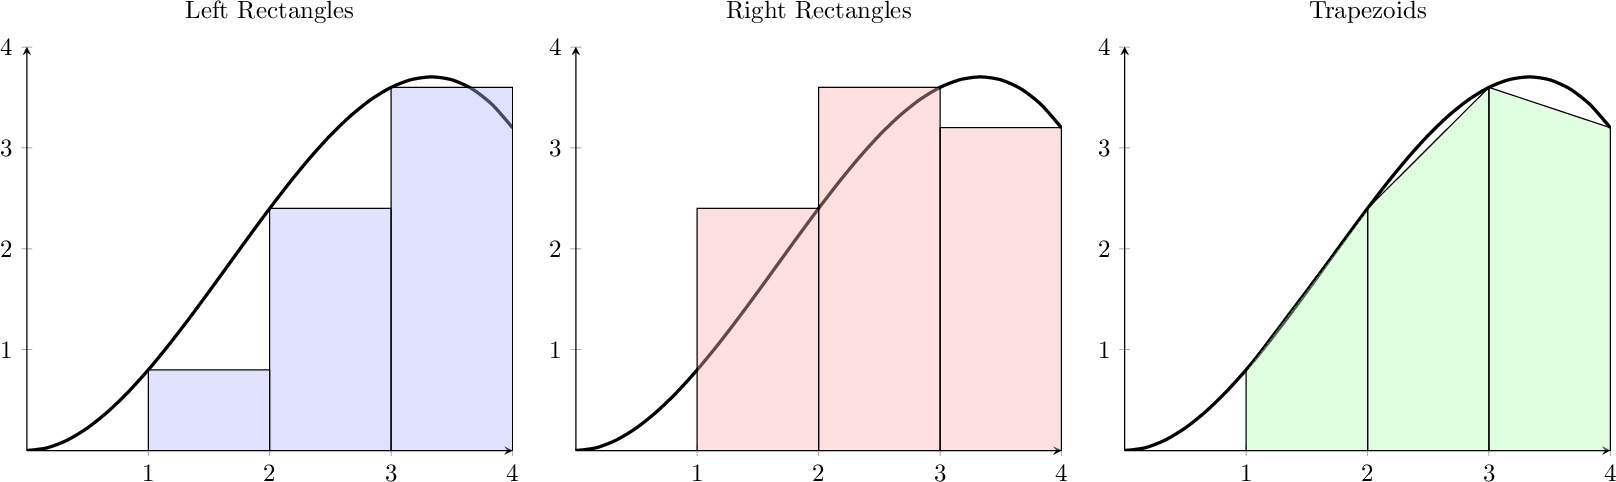

In [ ]:
from google.colab import files
from google.colab import drive

from IPython.display import Image

#drive.mount('/content/drive')

Image(filename='/content/drive/MyDrive/Figures/Trapezoidal.png')

Es fácil ver que los trapecios dan una mejor aproximación  que los rectángulos al menos en este caso particular.
  
  1.1 Aproxime las siguientes integrales utilizando los métodos de la regla de la mano derecha, de la mano izquierda, del punto medio y del trapecio, con valores de $n=1,5,10$ y $50$.

  $$\mbox{i) } A_1=\int_0^5 \frac{1}{5}x^2(5-x)\;dx=10.42$$
  $$\mbox{ii) } A_2=\int_0^3 3e^{-x}\sin(x)\;dx=1.56$$
  $$\mbox{iii) } A_3=\int_{-1}^2 x^5-2 x^4-x^2+6\;dx=12.3$$

  Construya una tabla por cada integral donde compare los cuatro métodos en terminos del número $n$ y los valores del error relativo :$$Error=\frac{A_i-A_{approx}}{A_i}, \quad i=1,2,3.$$

  Aquí $A_{approx}$ no es mas que el valor aproximado de la integral con algún método.

  1.2 Utilice argumentos geométricos para explicar por qué en cada uno de los  casos del punto anterior podría funcionar mejor el método del trapecio para aproximar integrales.

##1.1



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones para las reglas de integración
def regla_mano_izquierda(f, a, b, n):
    delta_x = (b - a) / n #Calcula el ancho de cada subintervalo
    suma = 0.0 #Acumula la suma de los valores de la funcion en los puntos izquierdos
    x_vals = [] #Almacena las coordenadas x de los puntos evaluados
    y_vals = [] #Almacena las coordenadas y de los puntos evaluados
    for i in range(n): #Itera sobre cada subintervalo
        x_i = a + i * delta_x #Calcula el punto izquierdo del subintervalo
        x_vals.append(x_i)
        y_vals.append(f(x_i))
        suma += f(x_i) #Suma el valor de la funcion en el punto izquierdo
    return suma * delta_x, x_vals, y_vals #Devuelve la aproximacion de la integral y los puntos evaluados

def regla_mano_derecha(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    x_vals = []
    y_vals = []
    for i in range(1, n + 1):
        x_i = a + i * delta_x
        x_vals.append(x_i)
        y_vals.append(f(x_i))
        suma += f(x_i)
    return suma * delta_x, x_vals, y_vals

def regla_punto_medio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    x_vals = []
    y_vals = []
    for i in range(n):
        x_i = a + (i + 0.5) * delta_x
        x_vals.append(x_i)
        y_vals.append(f(x_i))
        suma += f(x_i)
    return suma * delta_x, x_vals, y_vals

def regla_trapecio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    x_vals = []
    y_vals = []
    for i in range(n + 1):
        x_i = a + i * delta_x
        x_vals.append(x_i)
        y_vals.append(f(x_i))
        if i == 0 or i == n:
            suma += f(x_i) / 2
        else:
            suma += f(x_i)
    return suma * delta_x, x_vals, y_vals


  $$\mbox{i) } A_1=\int_0^5 \frac{1}{5}x^2(5-x)\;dx=10.42$$

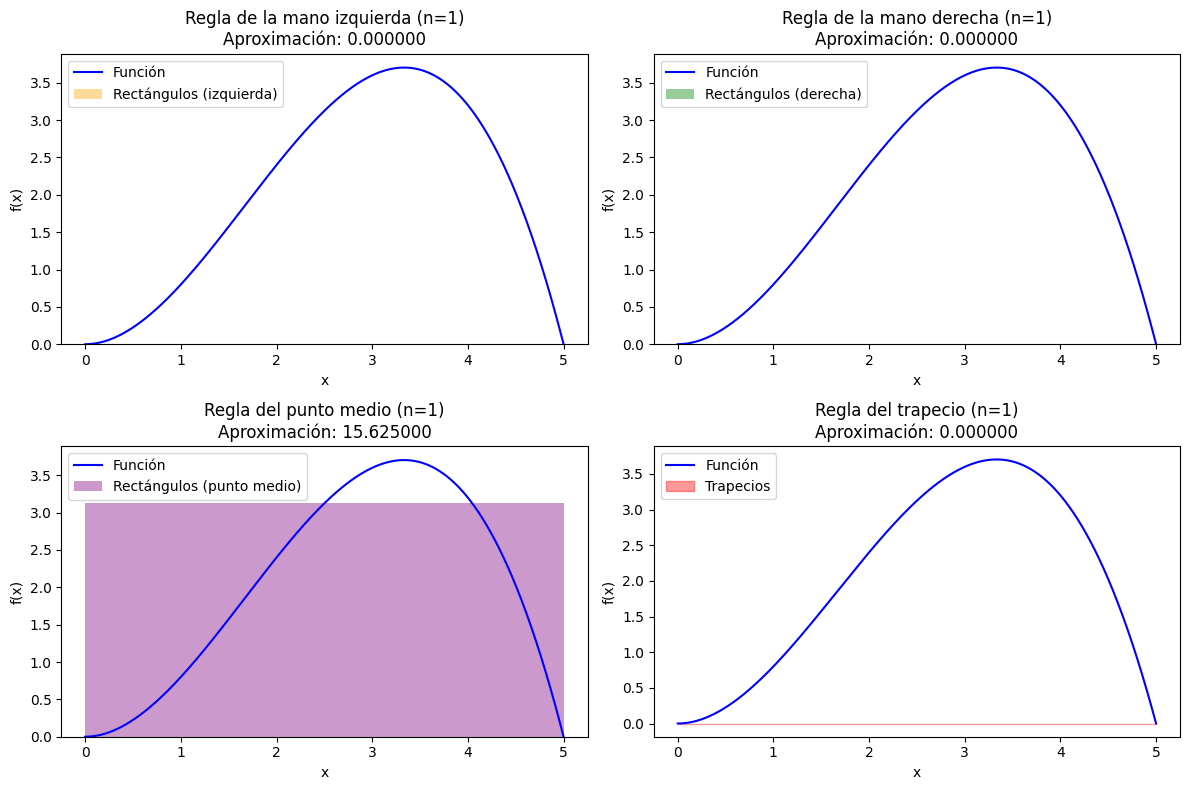

In [ ]:
# Función a integrar
def f(x):
    return (1/5) * x**2 * (5 - x)

# Límites de integración
a = 0
b = 5

# Número de subdivisiones
n = 1

# Calcular las aproximaciones y puntos para graficar
resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

# Crear la figura con 4 subgráficos
x = np.linspace(a, b, 1000) #Genera 1000 puntos entre a y b
y = f(x) #Evalua la funcion en dichos puntos

plt.figure(figsize=(12, 8)) #Tamaño de la figura

# Mano izquierda
plt.subplot(2, 2, 1) #Crea el primer subgrafico en una cuadricula 2x2
plt.plot(x, y, 'b-', label='Función') #Grafica la funcion continua
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)') #Grafica los rectangulos de la aproximacion
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}') #Añade un titulo con el valor de n y la aproximacion
plt.xlabel('x') #Nombra cada eje
plt.ylabel('f(x)') #Nombra cada eje
plt.legend() #Muestra la leyenda

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

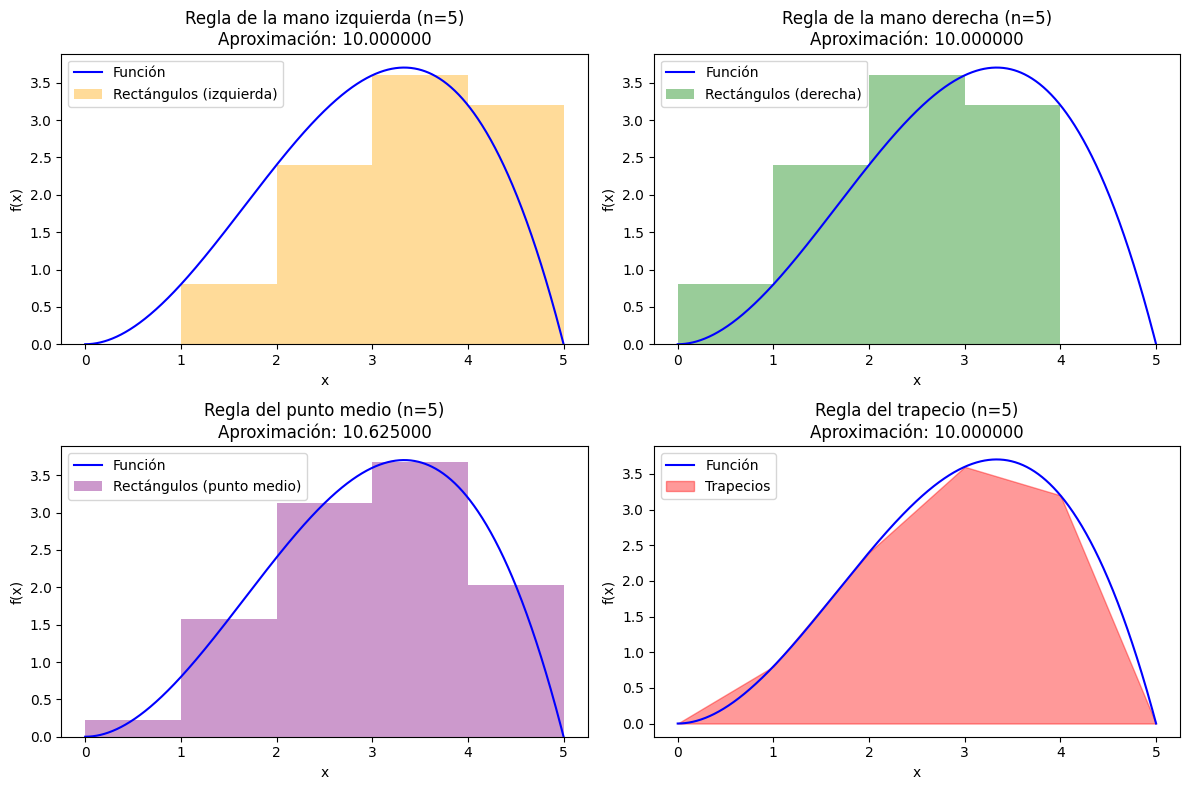

In [ ]:
def f(x):
    return (1/5) * x**2 * (5 - x)

a = 0
b = 5

n = 5

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

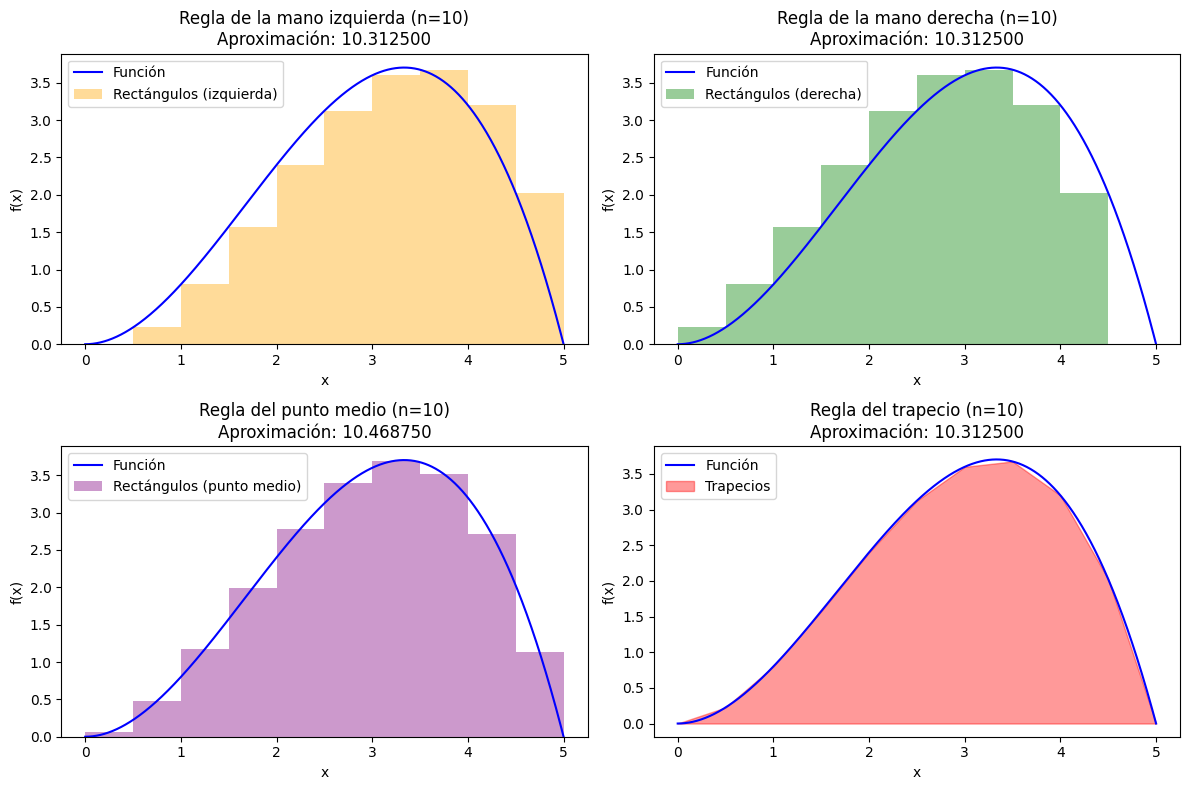

In [ ]:
def f(x):
    return (1/5) * x**2 * (5 - x)

a = 0
b = 5

n = 10

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

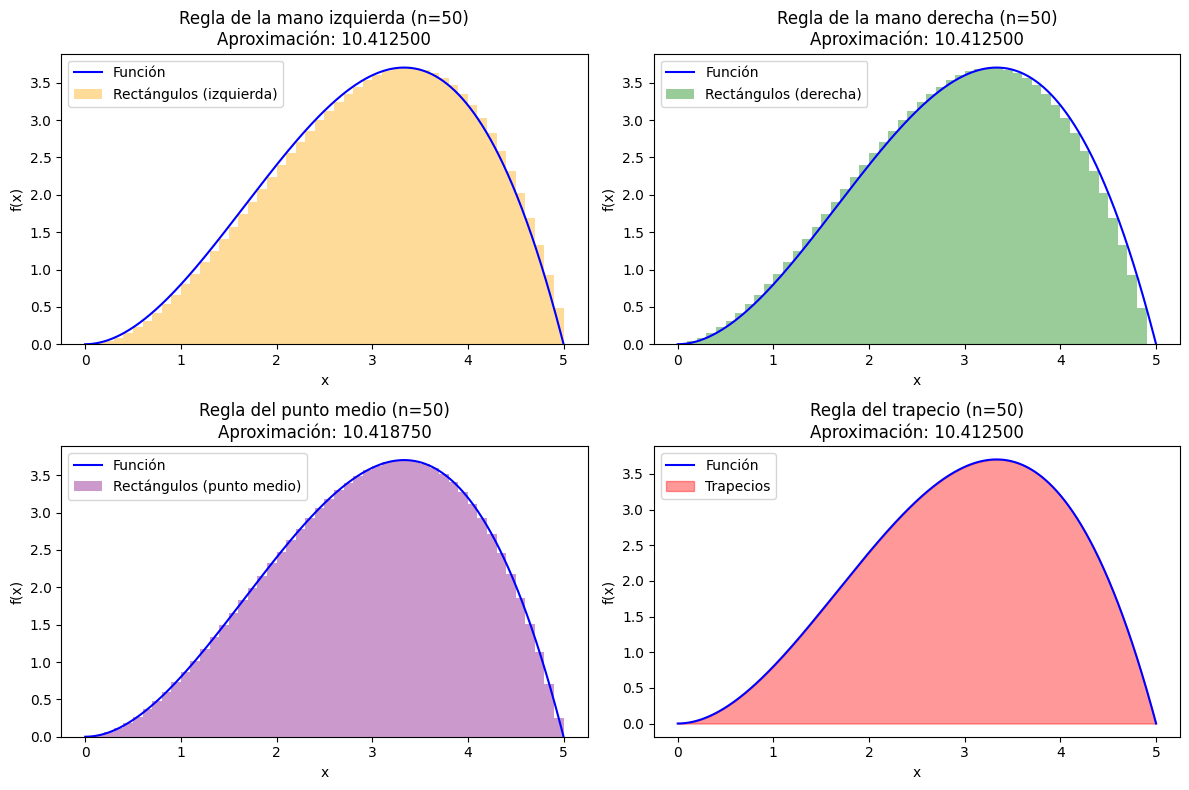

In [ ]:
def f(x):
    return (1/5) * x**2 * (5 - x)

a = 0
b = 5

n = 50

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

##Tablas del error relativo $i$ :

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import HTML

# Función a integrar
def f(x):
    return (1/5) * x**2 * (5 - x)

# Valor real de la integral
A_real = 10.42

# Límites de integración
a = 0
b = 5

# Número de subdivisiones
subdivisiones = [1, 5, 10, 50]

# Funciones para las reglas de integración
def regla_mano_izquierda(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_mano_derecha(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(1, n + 1):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_punto_medio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + (i + 0.5) * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_trapecio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n + 1):
        x_i = a + i * delta_x
        if i == 0 or i == n:
            suma += f(x_i) / 2
        else:
            suma += f(x_i)
    return suma * delta_x

# Función para calcular el error relativo
def error_relativo(A_real, A_approx):
    return abs((A_real - A_approx) / A_real)

# Función para crear y mostrar tablas estilizadas
def crear_tabla_estilizada(metodo, nombre_metodo):
    datos = {
        'n': [],
        'Aproximación': [],
        'Error Relativo': []
    }

    for n in subdivisiones:
        A_approx = metodo(f, a, b, n)
        error = error_relativo(A_real, A_approx)
        datos['n'].append(n)
        datos['Aproximación'].append(A_approx)
        datos['Error Relativo'].append(error)

    df = pd.DataFrame(datos)

    # Aplicar estilos a la tabla
    estilo_tabla = df.style.set_caption(f"Método: {nombre_metodo}") \
        .set_properties(**{'text-align': 'center'}) \
        .set_table_styles([{
            'selector': 'caption',
            'props': [
                ('color', '#FFFFFF'),  # Color del texto (blanco)
                ('background-color', '#8B0000'),  # Fondo rojo oscuro
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '10px'),  # Espaciado interno
                ('border-radius', '5px')  # Bordes redondeados
            ]
        }, {
            'selector': 'thead th',
            'props': [
                ('background-color', '#8B0000'),  # Rojo oscuro
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        }, {
            'selector': 'tbody td',
            'props': [
                ('border', '1px solid #8B0000'),  # Borde rojo oscuro
                ('text-align', 'center'),
                ('font-size', '12px')
            ]
        }])

    # Alternar colores de fondo para las filas
    estilo_tabla = estilo_tabla.apply(
        lambda x: ['background-color: #FFC0CB; color: black' if x.name % 2 == 0 else 'background-color: #FFB6C1; color: black' for _ in x],
        axis=1
    )

    # Convertir la tabla a HTML y centrarla
    tabla_html = estilo_tabla.to_html()
    tabla_centrada = f"""
    <div style="display: flex; justify-content: center;">
        {tabla_html}
    </div>
    """

    # Mostrar la tabla centrada
    display(HTML(tabla_centrada))

# Generar las tablas estilizadas para cada método
crear_tabla_estilizada(regla_mano_izquierda, "Regla de la mano izquierda")
crear_tabla_estilizada(regla_mano_derecha, "Regla de la mano derecha")
crear_tabla_estilizada(regla_punto_medio, "Regla del punto medio")
crear_tabla_estilizada(regla_trapecio, "Regla del trapecio")

,n,Aproximación,Error Relativo
0,1,0.000000,1.000000
1,5,10.000000,0.040307
2,10,10.312500,0.010317
3,50,10.412500,0.000720


,n,Aproximación,Error Relativo
0,1,0.000000,1.000000
1,5,10.000000,0.040307
2,10,10.312500,0.010317
3,50,10.412500,0.000720


,n,Aproximación,Error Relativo
0,1,15.625000,0.499520
1,5,10.625000,0.019674
2,10,10.468750,0.004679
3,50,10.418750,0.000120


,n,Aproximación,Error Relativo
0,1,0.000000,1.000000
1,5,10.000000,0.040307
2,10,10.312500,0.010317
3,50,10.412500,0.000720


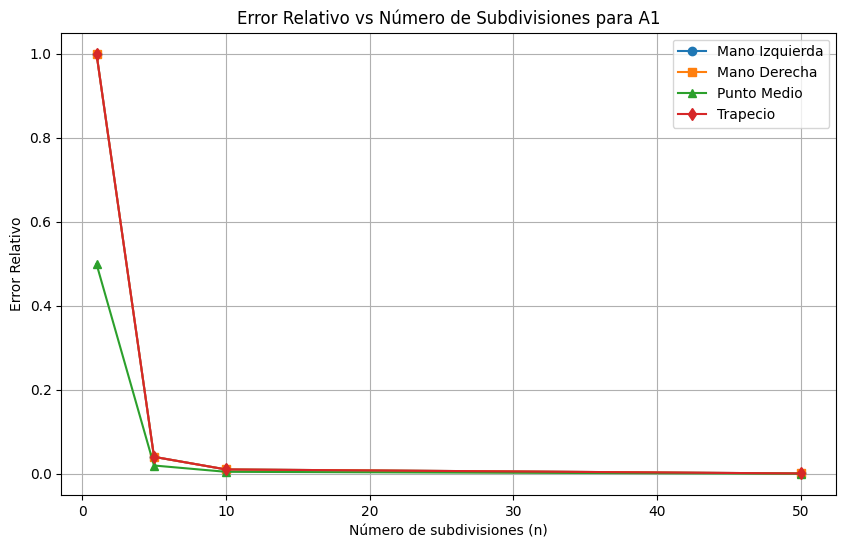

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función a integrar
def f1(x):
    return (1/5) * x**2 * (5 - x)

# Valor real de la integral
A_real1 = 10.42

# Límites de integración
a1 = 0
b1 = 5

# Número de subdivisiones
subdivisiones = [1, 5, 10, 50]

# Métodos de integración
def regla_mano_izquierda(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_mano_derecha(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(1, n + 1):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_punto_medio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + (i + 0.5) * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_trapecio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n + 1):
        x_i = a + i * delta_x
        if i == 0 or i == n:
            suma += f(x_i) / 2
        else:
            suma += f(x_i)
    return suma * delta_x

# Función para calcular el error relativo
def error_relativo(A_real, A_approx):
    return abs((A_real - A_approx) / A_real)

# Listas para almacenar los errores relativos
errores_izquierda1 = []
errores_derecha1 = []
errores_punto_medio1 = []
errores_trapecio1 = []

for n in subdivisiones:
    A_approx_izquierda = regla_mano_izquierda(f1, a1, b1, n)
    A_approx_derecha = regla_mano_derecha(f1, a1, b1, n)
    A_approx_punto_medio = regla_punto_medio(f1, a1, b1, n)
    A_approx_trapecio = regla_trapecio(f1, a1, b1, n)

    errores_izquierda1.append(error_relativo(A_real1, A_approx_izquierda))
    errores_derecha1.append(error_relativo(A_real1, A_approx_derecha))
    errores_punto_medio1.append(error_relativo(A_real1, A_approx_punto_medio))
    errores_trapecio1.append(error_relativo(A_real1, A_approx_trapecio))

# Graficar los errores relativos
plt.figure(figsize=(10, 6))
plt.plot(subdivisiones, errores_izquierda1, label='Mano Izquierda', marker='o')
plt.plot(subdivisiones, errores_derecha1, label='Mano Derecha', marker='s')
plt.plot(subdivisiones, errores_punto_medio1, label='Punto Medio', marker='^')
plt.plot(subdivisiones, errores_trapecio1, label='Trapecio', marker='d')
plt.xlabel('Número de subdivisiones (n)')
plt.ylabel('Error Relativo')
plt.title('Error Relativo vs Número de Subdivisiones para A1')
plt.legend()
plt.grid(True)
plt.show()


  $$\mbox{ii) } A_2=\int_0^3 3e^{-x}\sin(x)\;dx=1.56$$


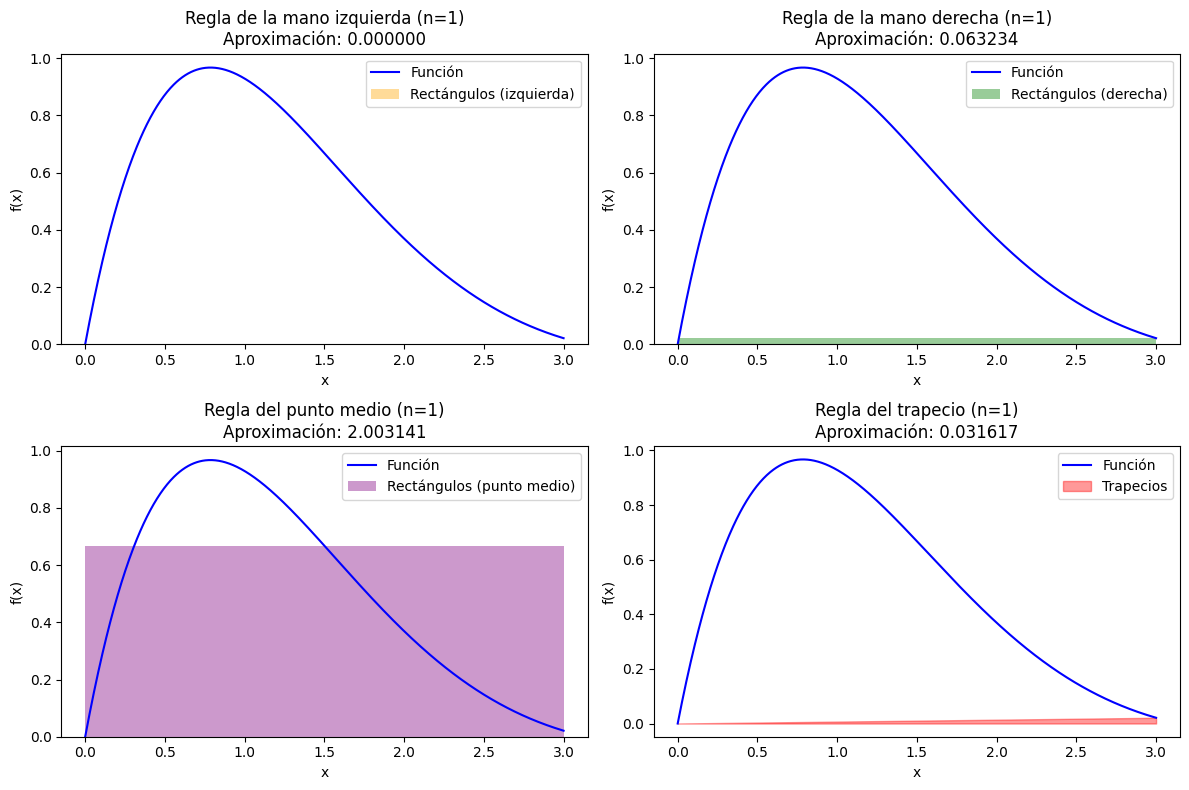

In [ ]:
def f(x):
    return 3*np.exp(-x)*np.sin(x)

a = 0
b = 3

n = 1

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

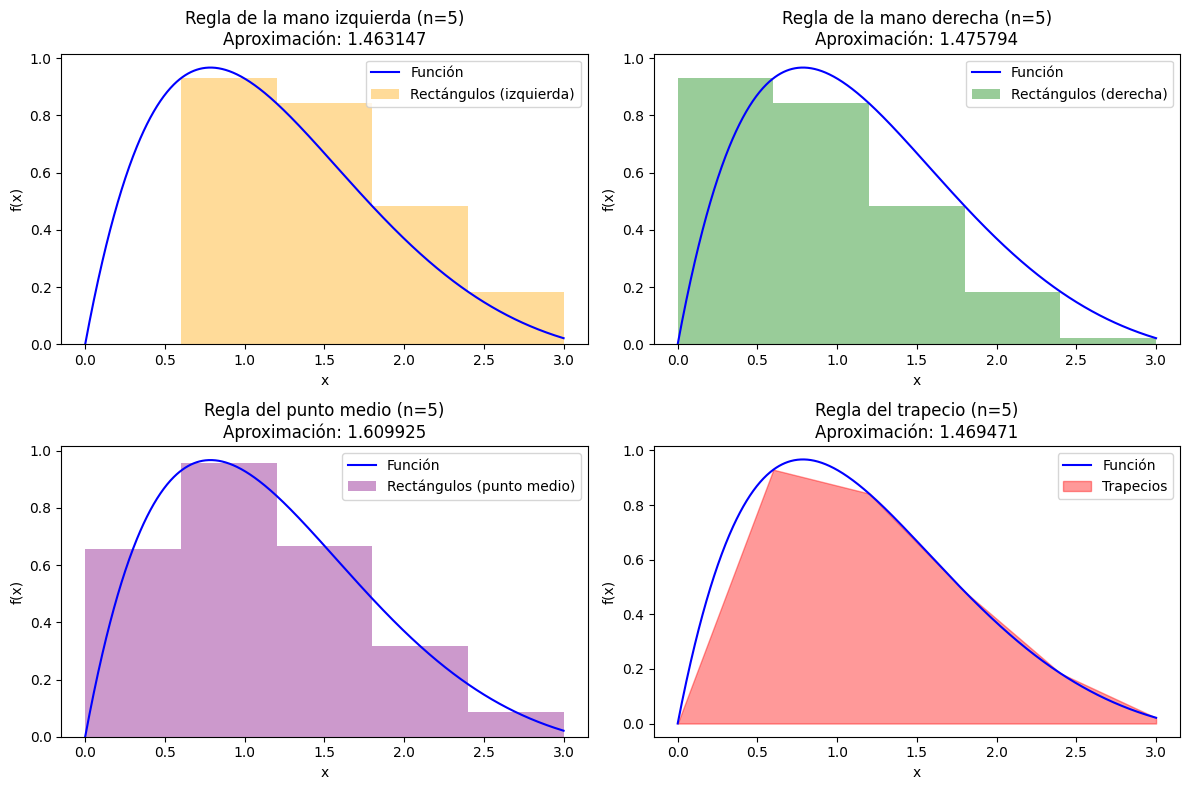

In [ ]:
def f(x):
    return 3*np.exp(-x)*np.sin(x)

a = 0
b = 3

n = 5

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

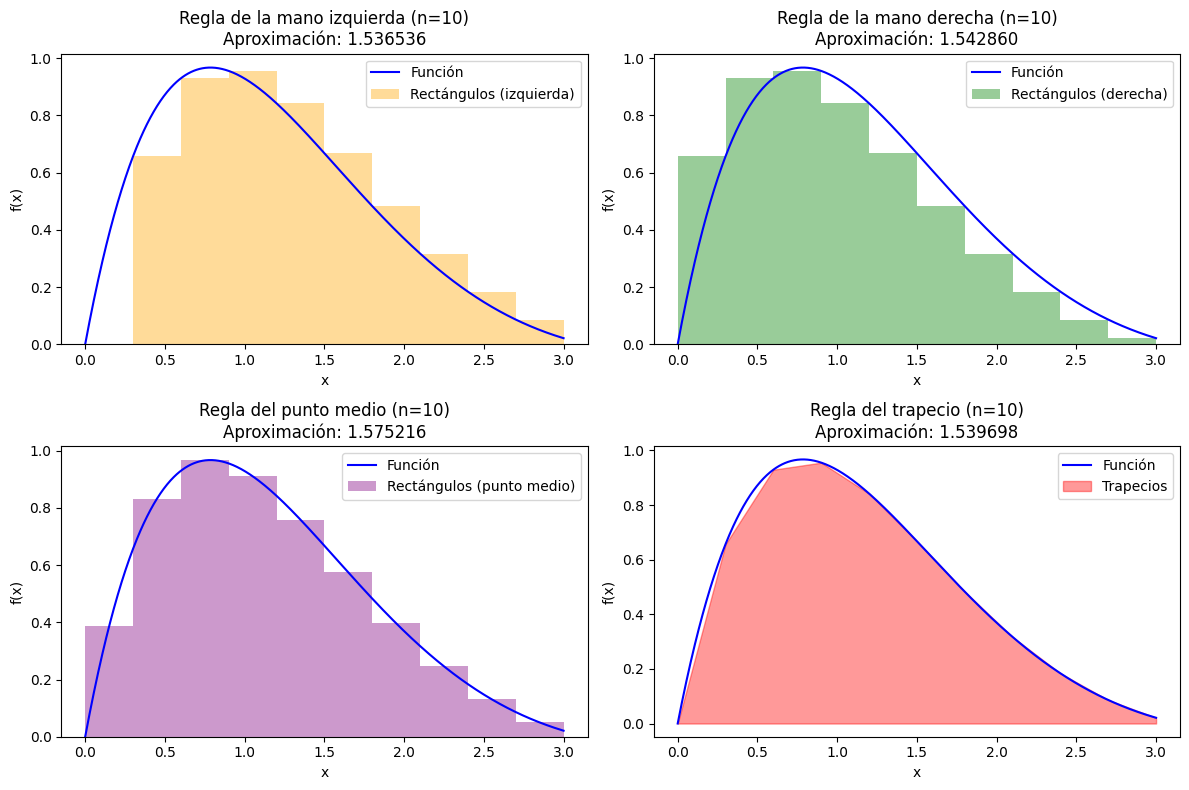

In [ ]:
def f(x):
    return 3*np.exp(-x)*np.sin(x)

a = 0
b = 3

n = 10

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

#Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

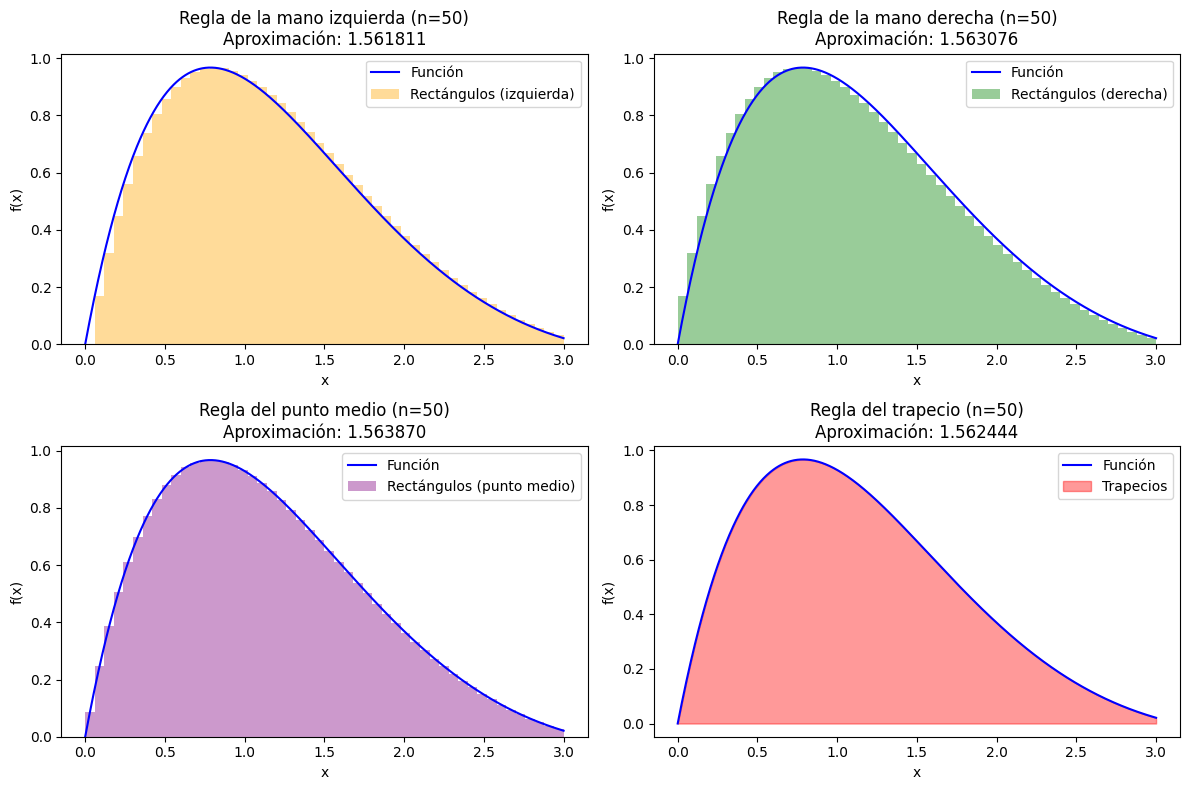

In [ ]:
def f(x):
    return 3*np.exp(-x)*np.sin(x)

a = 0
b = 3

n = 50

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

## Tablas de error relativo $ii$:

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import HTML

# Función a integrar
def f(x):
    return 3 * np.exp(-x) * np.sin(x)

# Valor real de la integral
A_real = 1.56

# Límites de integración
a = 0
b = 3

# Número de subdivisiones
subdivisiones = [1, 5, 10, 50]

# Funciones para las reglas de integración
def regla_mano_izquierda(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_mano_derecha(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(1, n + 1):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_punto_medio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + (i + 0.5) * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_trapecio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n + 1):
        x_i = a + i * delta_x
        if i == 0 or i == n:
            suma += f(x_i) / 2
        else:
            suma += f(x_i)
    return suma * delta_x

# Función para calcular el error relativo
def error_relativo(A_real, A_approx):
    return abs((A_real - A_approx) / A_real)

# Función para crear y mostrar tablas estilizadas
def crear_tabla_estilizada(metodo, nombre_metodo):
    datos = {
        'n': [],
        'Aproximación': [],
        'Error Relativo': []
    }

    for n in subdivisiones:
        A_approx = metodo(f, a, b, n)
        error = error_relativo(A_real, A_approx)
        datos['n'].append(n)
        datos['Aproximación'].append(A_approx)
        datos['Error Relativo'].append(error)

    df = pd.DataFrame(datos)

    # Aplicar estilos a la tabla
    estilo_tabla = df.style.set_caption(f"Método: {nombre_metodo}") \
        .set_properties(**{'text-align': 'center'}) \
        .set_table_styles([{
            'selector': 'caption',
            'props': [
                ('color', '#FFFFFF'),  # Color del texto (blanco)
                ('background-color', '#228B22'),  # Fondo verde oscuro
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '10px'),  # Espaciado interno
                ('border-radius', '5px')  # Bordes redondeados
            ]
        }, {
            'selector': 'thead th',
            'props': [
                ('background-color', '#228B22'),  # Verde oscuro
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        }, {
            'selector': 'tbody td',
            'props': [
                ('border', '1px solid #228B22'),  # Borde verde oscuro
                ('text-align', 'center'),
                ('font-size', '12px')
            ]
        }])

    # Alternar colores de fondo para las filas
    estilo_tabla = estilo_tabla.apply(
        lambda x: ['background-color: #90EE90; color: black' if x.name % 2 == 0 else 'background-color: #98FB98; color: black' for _ in x],
        axis=1
    )

    # Convertir la tabla a HTML y centrarla
    tabla_html = estilo_tabla.to_html()
    tabla_centrada = f"""
    <div style="display: flex; justify-content: center;">
        {tabla_html}
    </div>
    """

    # Mostrar la tabla centrada
    display(HTML(tabla_centrada))

# Generar las tablas estilizadas para cada método
crear_tabla_estilizada(regla_mano_izquierda, "Regla de la mano izquierda")
crear_tabla_estilizada(regla_mano_derecha, "Regla de la mano derecha")
crear_tabla_estilizada(regla_punto_medio, "Regla del punto medio")
crear_tabla_estilizada(regla_trapecio, "Regla del trapecio")

,n,Aproximación,Error Relativo
0,1,0.000000,1.000000
1,5,1.463147,0.062085
2,10,1.536536,0.015041
3,50,1.561811,0.001161


,n,Aproximación,Error Relativo
0,1,0.063234,0.959466
1,5,1.475794,0.053978
2,10,1.542860,0.010987
3,50,1.563076,0.001972


,n,Aproximación,Error Relativo
0,1,2.003141,0.284065
1,5,1.609925,0.032003
2,10,1.575216,0.009754
3,50,1.563870,0.002480


,n,Aproximación,Error Relativo
0,1,0.031617,0.979733
1,5,1.469471,0.058032
2,10,1.539698,0.013014
3,50,1.562444,0.001566


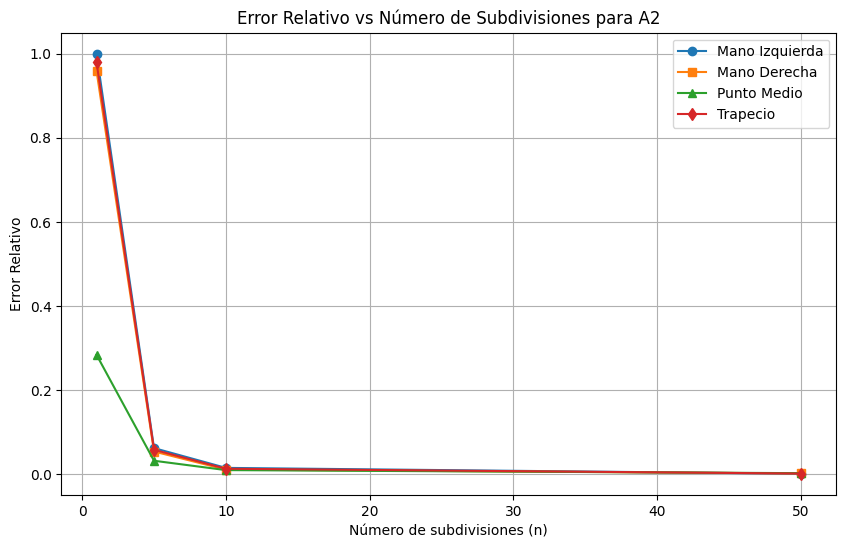

In [ ]:
# Función a integrar
def f2(x):
    return 3 * np.exp(-x) * np.sin(x)

# Valor real de la integral
A_real2 = 1.56

# Límites de integración
a2 = 0
b2 = 3

# Listas para almacenar los errores relativos
errores_izquierda2 = []
errores_derecha2 = []
errores_punto_medio2 = []
errores_trapecio2 = []

for n in subdivisiones:
    A_approx_izquierda = regla_mano_izquierda(f2, a2, b2, n)
    A_approx_derecha = regla_mano_derecha(f2, a2, b2, n)
    A_approx_punto_medio = regla_punto_medio(f2, a2, b2, n)
    A_approx_trapecio = regla_trapecio(f2, a2, b2, n)

    errores_izquierda2.append(error_relativo(A_real2, A_approx_izquierda))
    errores_derecha2.append(error_relativo(A_real2, A_approx_derecha))
    errores_punto_medio2.append(error_relativo(A_real2, A_approx_punto_medio))
    errores_trapecio2.append(error_relativo(A_real2, A_approx_trapecio))

# Graficar los errores relativos
plt.figure(figsize=(10, 6))
plt.plot(subdivisiones, errores_izquierda2, label='Mano Izquierda', marker='o')
plt.plot(subdivisiones, errores_derecha2, label='Mano Derecha', marker='s')
plt.plot(subdivisiones, errores_punto_medio2, label='Punto Medio', marker='^')
plt.plot(subdivisiones, errores_trapecio2, label='Trapecio', marker='d')
plt.xlabel('Número de subdivisiones (n)')
plt.ylabel('Error Relativo')
plt.title('Error Relativo vs Número de Subdivisiones para A2')
plt.legend()
plt.grid(True)
plt.show()


  $$\mbox{iii) } A_3=\int_{-1}^2 x^5-2 x^4-x^2+6\;dx=12.3$$

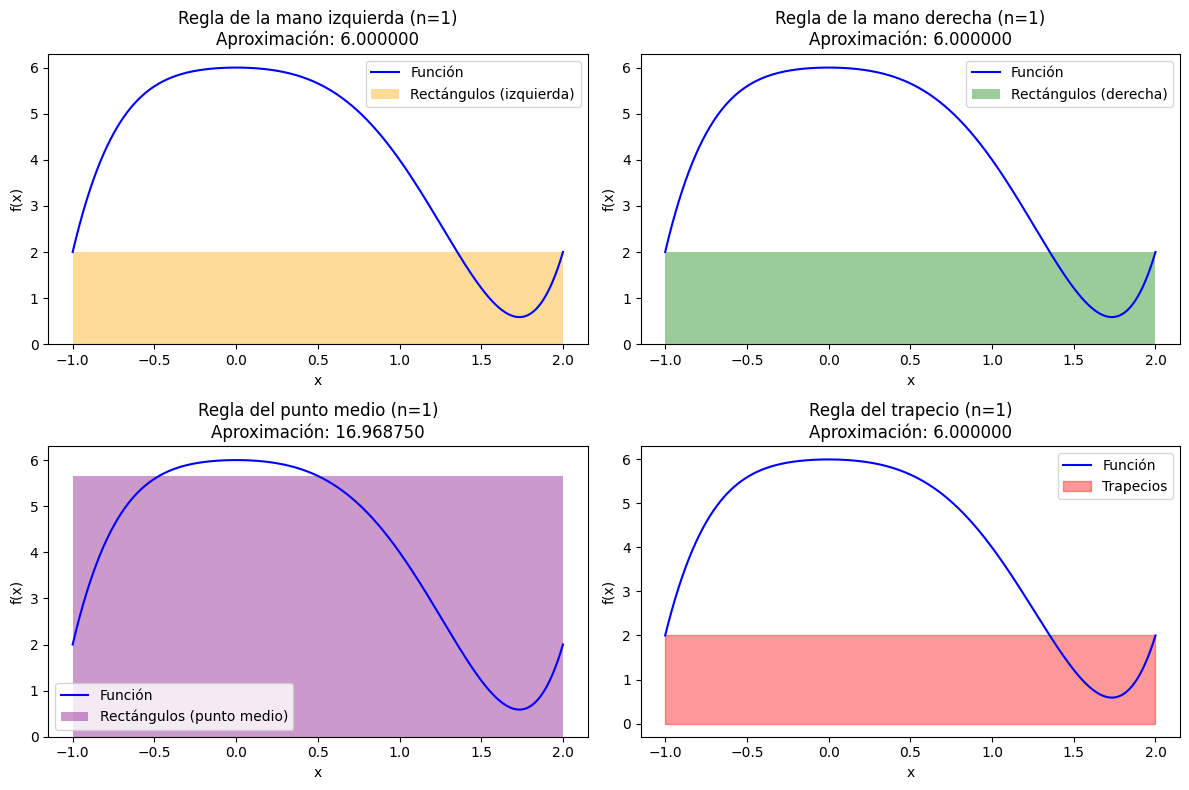

In [ ]:
def f(x):
    return x**5-2*x**4-x**2+6

a = -1
b = 2

n = 1

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

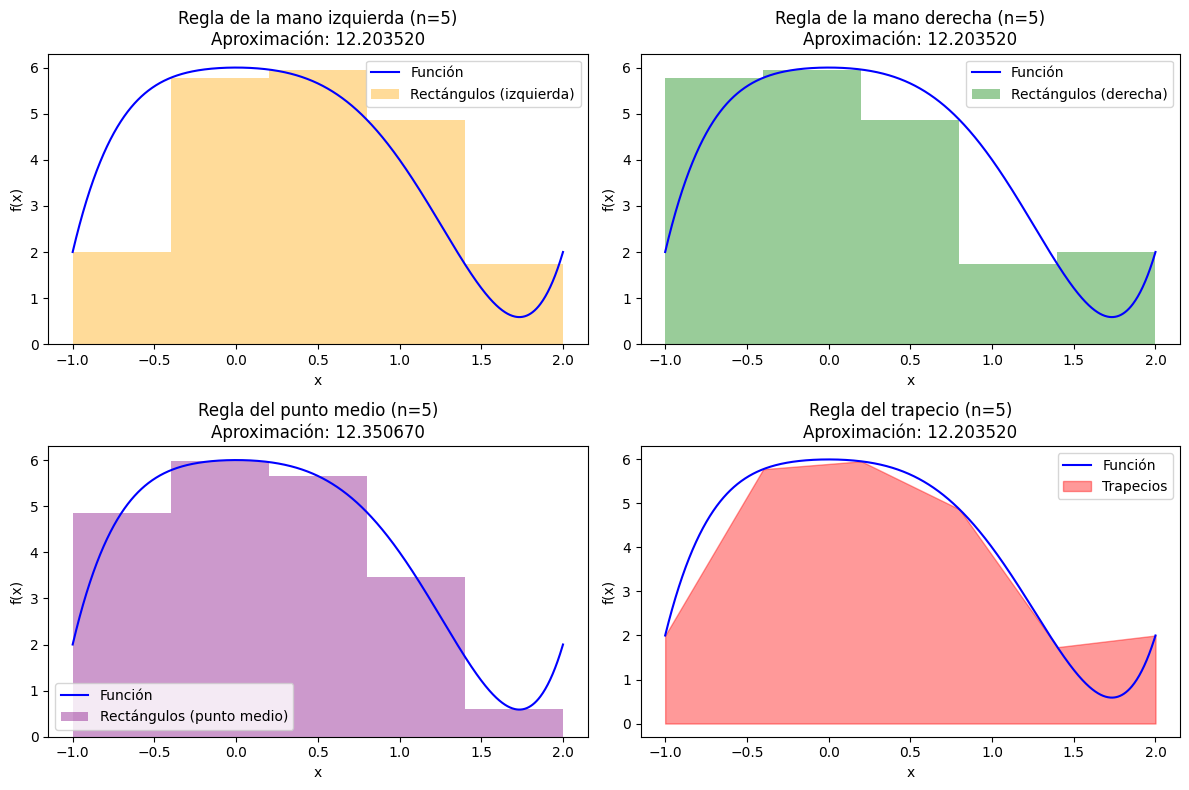

In [ ]:
def f(x):
    return x**5-2*x**4-x**2+6

a = -1
b = 2

n = 5

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

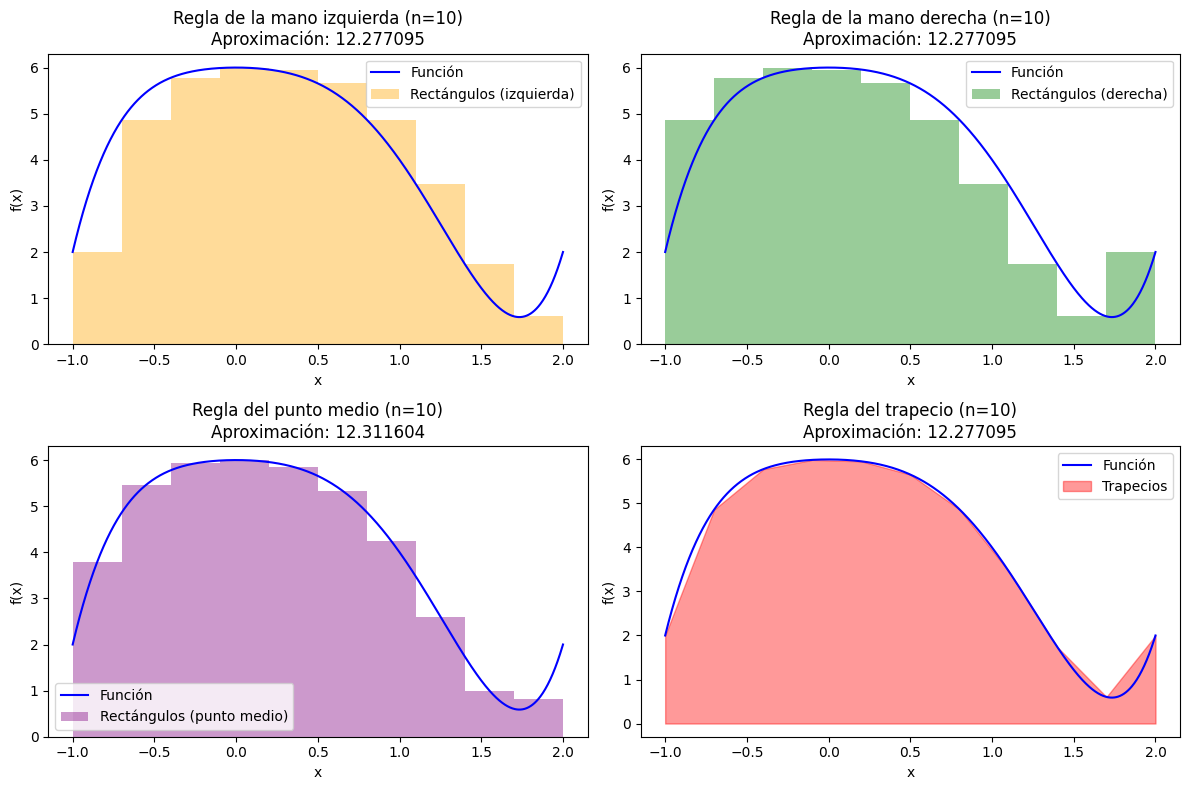

In [ ]:
def f(x):
    return x**5-2*x**4-x**2+6

a = -1
b = 2

n = 10

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)


x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

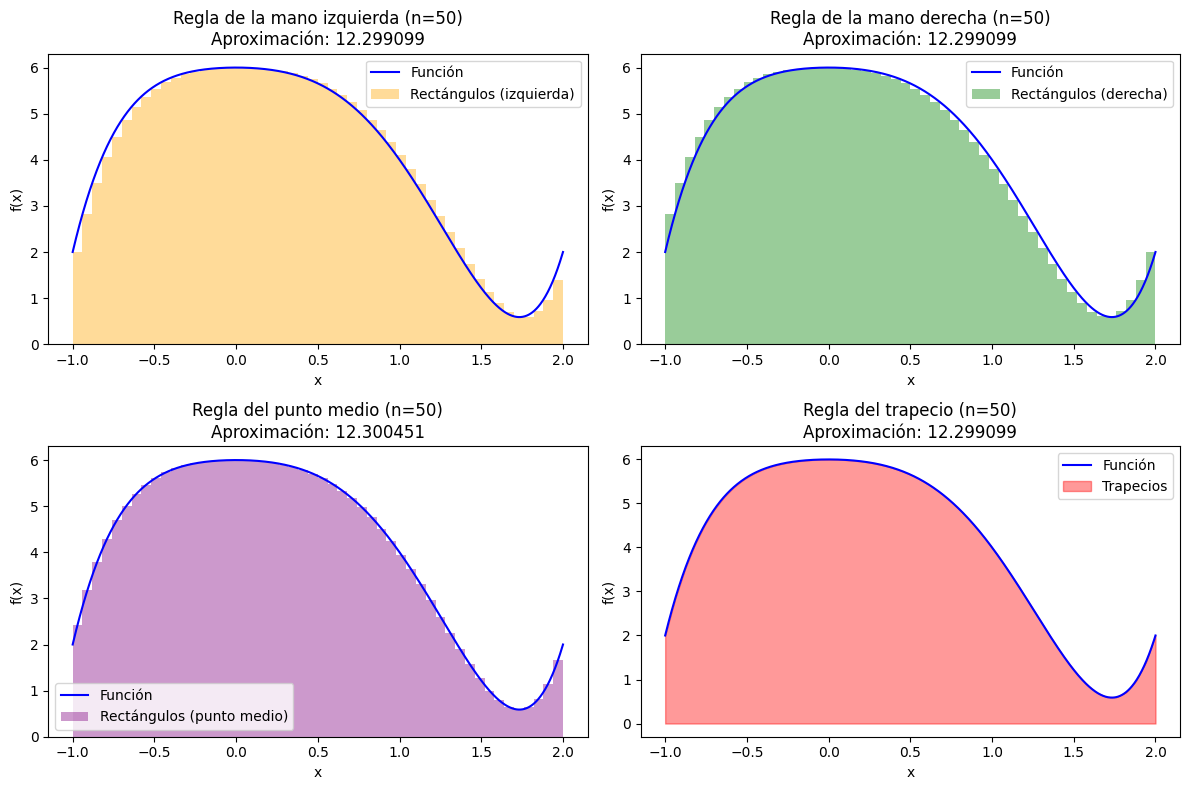

In [ ]:
def f(x):
    return x**5-2*x**4-x**2+6

a = -1
b = 2

n = 50

resultado_izquierda, x_izquierda, y_izquierda = regla_mano_izquierda(f, a, b, n)
resultado_derecha, x_derecha, y_derecha = regla_mano_derecha(f, a, b, n)
resultado_punto_medio, x_punto_medio, y_punto_medio = regla_punto_medio(f, a, b, n)
resultado_trapecio, x_trapecio, y_trapecio = regla_trapecio(f, a, b, n)

x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(12, 8))

# Mano izquierda
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_izquierda, y_izquierda, width=(b - a)/n, alpha=0.4, align='edge', color='orange', label='Rectángulos (izquierda)')
plt.title(f'Regla de la mano izquierda (n={n})\nAproximación: {resultado_izquierda:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Mano derecha
plt.subplot(2, 2, 2)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_derecha, y_derecha, width=-(b - a)/n, alpha=0.4, align='edge', color='green', label='Rectángulos (derecha)')
plt.title(f'Regla de la mano derecha (n={n})\nAproximación: {resultado_derecha:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Punto medio
plt.subplot(2, 2, 3)
plt.plot(x, y, 'b-', label='Función')
plt.bar(x_punto_medio, y_punto_medio, width=(b - a)/n, alpha=0.4, color='purple', label='Rectángulos (punto medio)')
plt.title(f'Regla del punto medio (n={n})\nAproximación: {resultado_punto_medio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Trapecio
plt.subplot(2, 2, 4)
plt.plot(x, y, 'b-', label='Función')
plt.fill_between(x_trapecio, y_trapecio, alpha=0.4, color='red', label='Trapecios')
plt.title(f'Regla del trapecio (n={n})\nAproximación: {resultado_trapecio:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.tight_layout()
plt.show()

## Tablas de error relativo $iii$:

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import HTML

# Función a integrar
def f(x):
    return x**5 - 2*x**4 - x**2 + 6

# Valor real de la integral
A_real = 12.3

# Límites de integración
a = -1
b = 2

# Número de subdivisiones
subdivisiones = [1, 5, 10, 50]

# Funciones para las reglas de integración
def regla_mano_izquierda(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_mano_derecha(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(1, n + 1):
        x_i = a + i * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_punto_medio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n):
        x_i = a + (i + 0.5) * delta_x
        suma += f(x_i)
    return suma * delta_x

def regla_trapecio(f, a, b, n):
    delta_x = (b - a) / n
    suma = 0.0
    for i in range(n + 1):
        x_i = a + i * delta_x
        if i == 0 or i == n:
            suma += f(x_i) / 2
        else:
            suma += f(x_i)
    return suma * delta_x

# Función para calcular el error relativo
def error_relativo(A_real, A_approx):
    return abs((A_real - A_approx) / A_real)

# Función para crear y mostrar tablas estilizadas
def crear_tabla_estilizada(metodo, nombre_metodo):
    datos = {
        'n': [],
        'Aproximación': [],
        'Error Relativo': []
    }

    for n in subdivisiones:
        A_approx = metodo(f, a, b, n)
        error = error_relativo(A_real, A_approx)
        datos['n'].append(n)
        datos['Aproximación'].append(A_approx)
        datos['Error Relativo'].append(error)

    df = pd.DataFrame(datos)

    # Aplicar estilos a la tabla
    estilo_tabla = df.style.set_caption(f"Método: {nombre_metodo}") \
        .set_properties(**{'text-align': 'center'}) \
        .set_table_styles([{
            'selector': 'caption',
            'props': [
                ('color', '#FFFFFF'),  # Color del texto (blanco)
                ('background-color', '#1E90FF'),  # Fondo azul
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '10px'),  # Espaciado interno
                ('border-radius', '5px')  # Bordes redondeados
            ]
        }, {
            'selector': 'thead th',
            'props': [
                ('background-color', '#1E90FF'),  # Azul
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        }, {
            'selector': 'tbody td',
            'props': [
                ('border', '1px solid #1E90FF'),  # Borde azul
                ('text-align', 'center'),
                ('font-size', '12px')
            ]
        }])

    # Alternar colores de fondo para las filas
    estilo_tabla = estilo_tabla.apply(
        lambda x: ['background-color: #87CEEB; color: black' if x.name % 2 == 0 else 'background-color: #ADD8E6; color: black' for _ in x],
        axis=1
    )

    # Convertir la tabla a HTML y centrarla
    tabla_html = estilo_tabla.to_html()
    tabla_centrada = f"""
    <div style="display: flex; justify-content: center;">
        {tabla_html}
    </div>
    """

    # Mostrar la tabla centrada
    display(HTML(tabla_centrada))

# Generar las tablas estilizadas para cada método
crear_tabla_estilizada(regla_mano_izquierda, "Regla de la mano izquierda")
crear_tabla_estilizada(regla_mano_derecha, "Regla de la mano derecha")
crear_tabla_estilizada(regla_punto_medio, "Regla del punto medio")
crear_tabla_estilizada(regla_trapecio, "Regla del trapecio")

,n,Aproximación,Error Relativo
0,1,6.000000,0.512195
1,5,12.203520,0.007844
2,10,12.277095,0.001862
3,50,12.299099,0.000073


,n,Aproximación,Error Relativo
0,1,6.000000,0.512195
1,5,12.203520,0.007844
2,10,12.277095,0.001862
3,50,12.299099,0.000073


,n,Aproximación,Error Relativo
0,1,16.968750,0.379573
1,5,12.350670,0.004120
2,10,12.311604,0.000943
3,50,12.300451,0.000037


,n,Aproximación,Error Relativo
0,1,6.000000,0.512195
1,5,12.203520,0.007844
2,10,12.277095,0.001862
3,50,12.299099,0.000073


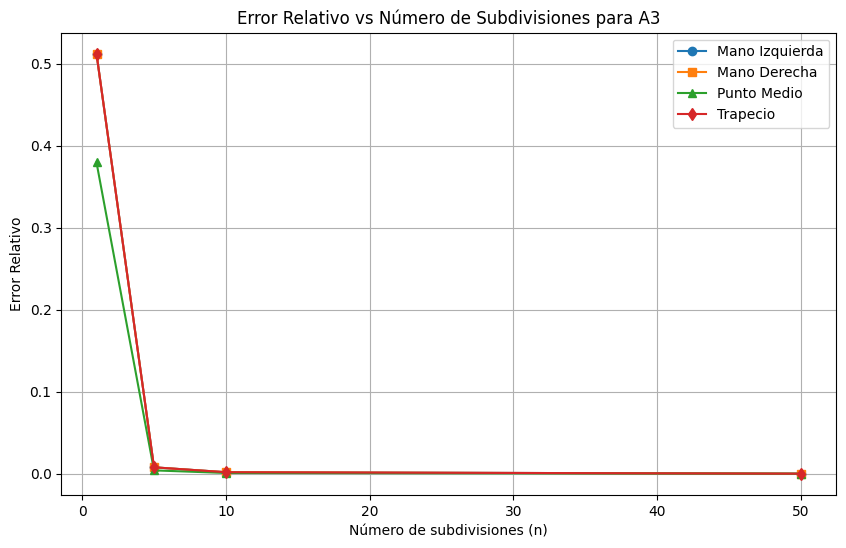

In [ ]:
# Función a integrar
def f3(x):
    return x**5 - 2*x**4 - x**2 + 6

# Valor real de la integral
A_real3 = 12.3

# Límites de integración
a3 = -1
b3 = 2

# Listas para almacenar los errores relativos
errores_izquierda3 = []
errores_derecha3 = []
errores_punto_medio3 = []
errores_trapecio3 = []

for n in subdivisiones:
    A_approx_izquierda = regla_mano_izquierda(f3, a3, b3, n)
    A_approx_derecha = regla_mano_derecha(f3, a3, b3, n)
    A_approx_punto_medio = regla_punto_medio(f3, a3, b3, n)
    A_approx_trapecio = regla_trapecio(f3, a3, b3, n)

    errores_izquierda3.append(error_relativo(A_real3, A_approx_izquierda))
    errores_derecha3.append(error_relativo(A_real3, A_approx_derecha))
    errores_punto_medio3.append(error_relativo(A_real3, A_approx_punto_medio))
    errores_trapecio3.append(error_relativo(A_real3, A_approx_trapecio))

# Graficar los errores relativos
plt.figure(figsize=(10, 6))
plt.plot(subdivisiones, errores_izquierda3, label='Mano Izquierda', marker='o')
plt.plot(subdivisiones, errores_derecha3, label='Mano Derecha', marker='s')
plt.plot(subdivisiones, errores_punto_medio3, label='Punto Medio', marker='^')
plt.plot(subdivisiones, errores_trapecio3, label='Trapecio', marker='d')
plt.xlabel('Número de subdivisiones (n)')
plt.ylabel('Error Relativo')
plt.title('Error Relativo vs Número de Subdivisiones para A3')
plt.legend()
plt.grid(True)
plt.show()

##1.2

Generalmente, el metodo del trapecio resulta mas precisos que los demas metodos de aproximacion de integrales mencionados, esto debido a que, a diferencia de dichos metodos, este no asume que la funcion se mantiene constante en cada subintervalo, sino que conecta los valores de los extremos de cada subintevalo, logrando asi ser mas fiel a la curvatura de la funcion, disminuyendo de tal manera el error que se presenta en la aproximacion, y logrando que la presicion de este aumente de manera mas rapida, es decir, que sea mas preciso con menos subintervalos que los necesarios en los otros metodos.

2. (24 ptos) **Regla de Simpson**. La regla trapezoidal hace un trabajo decente al aproximar integrales, pero finalmente  usa funciones lineales para aproximar $f(x)$  y la precisión puede verse afectada si el tamaño del paso es demasiado grande o la función altamente no lineal. Probablemente notará que la regla trapezoidal dará una respuesta exacta si tuviera que integrar una función lineal o constante. Un enfoque potencialmente mejor sería obtener una integral que evalúe exactamente las funciones cuadráticas. Para hacer esto necesitamos evaluar la función en tres puntos (no en dos como la regla trapezoidal). Vamos a integrar la función $f(x)$ usando tres puntos $(a,f(a))$, $(m,f(m))$ y $(b,f(b))$.  Para ello necesitamos encontrar constantes $A_1$, $A_2$ y $A_3$ tales que

$$\int_a^b f(x)\;dx=A_1f(a)+A_2f(m)+A_3f(b).$$
  
  2.1 Explique la  afirmación inicial "La regla trapezoidal hace un trabajo decente al aproximar integrales, pero finalmente  usa funciones lineales para aproximar $f(x)$" y por qué encontrar las constantes $A_i$, implica poder hallar una aproximación de funciones cuadráticas.
  
  2.2 Muestre que:

  $$\int_a^b 1\;dx=b-a=A_1+A_2+A_3$$
  $$\int_a^b x\;dx=\frac{b^2-a^2}{2}=A_1a+A_2\left(\frac{a+b}{2}\right)+A_3b$$
  $$\int_a^b x^2\;dx=\frac{b^3-a^3}{3}=A_1a^2+A_2\left(\frac{a+b}{2}\right)^2+A_3b^2$$

  Se puede mostrar, mas adelante en este curso, que el sistema lineal anterior tiene como solución única:

  $$A_1=A_3=\frac{b-a}{6},\,A_2=4\frac{b-a}{6}.$$

   2.3 Implemente una función en python que le permita calcular  el valor de $I_{approx}=\frac{b-a}{6}\left(f(a)+4f(\frac{a+b}{2})+f(b)\right)$.  Utilice la función construida para aproximar el valor  del área bajo las curvas $-\frac{1}{2}x^2+3.3x-2$ y $\frac{1}{5}x^2(5-x)$ en el intervalo $[1,4]$. ¿Qué notas acerca de las dos áreas? ¿Qué te dice este problema sobre la fórmula que derivamos arriba?

   2.4 Diseñe un applet en GeoGebra que permita interpretar geométricamente el significado de  $I_{approx}$ con respecto al área bajo las curvas anteriores en el intervalo $[1,4]$.

# **2.1**
La afirmación "La regla trapezoidal hace un trabajo decente al aproximar integrales, pero finalmente usa funciones lineales para aproximar
$f(x)$ indica lo siguiente:

La regla trapezoidal divide el intervalo $[a,b]$ en segmentos y asume que la curva puede aproximarse razonablemente bien con líneas rectas. Es decir, la integral se calcula como la suma de las áreas de los trapecios formados entre
$a,b$ y la función $f(x)$.

Sin embargo, este método pierde precisión cuando $f(x)$ no se comporta como una línea recta (es decir, no es lineal o constante) porque las líneas rectas no pueden capturar la curvatura de la función.

-----
Para usar la regla de Simpson, estamos diciendo: "Voy a aproximar la integral de $f(x)$ con una parábola que pase por tres puntos: $(a, f(a))$, $(m, f(m))$, y $(b, f(b))$."

El problema es que una parábola tiene esta forma general:

$P(x) = c_1 x^2 + c_2 x + c_3,$

y para que esta parábola se ajuste bien, debemos encontrar los números exactos ($c_1$, $c_2$, $c_3$) que la definan. Eso nos lleva a los $A_1$, $A_2$, $A_3$, que son el resultado de integrar esta parábola entre $a$ y $b$.

Las constantes $A_1$, $A_2$, $A_3$ son los resultados del cálculo matemático que asegura que la fórmula de Simpson sea correcta y capture la forma de la parábola.


# **2.2**
SOLUCIÓN:
  -  Existe una aproximacion en el enunciado de la forma: $$\int_a^b f(x)\;dx=A_1f(a)+A_2f(m)+A_3f(b).$$
  

  1. Primera integral (constante) dónde  $$\int_a^b 1\;dx=b-a=A_1+A_2+A_3$$
  - Se aplica la regla de Simpson, donde $f(x)=1$ :

  $A_1f(a) + A_2f(m)+A_3f(b)= A_1(1) + A_2(1)+A_3(1)= A_1 + A_2 + A_3$

  - Se realiza la integral $\int_{a}^{b} 1 dx$

    $\int_{a}^{b} 1 dx = x \Big|_{a}^{b} = b - a$
  - Se igualan los dos resultados anteriores con el fin de tener una aproximación más exacta:

  $A_1 + A_2 + A_3 = b - a $

  2. Segunda integral (líneal) dónde $$\int_a^b x\;dx=\frac{b^2-a^2}{2}=A_1a+A_2\left(\frac{a+b}{2}\right)+A_3b$$

  - Se realiza la integral $\int_a^b xdx$

  $\int_a^b xdx = \frac{x^2}{2} \Big|_{a}^{b} = \frac {b^2}{2} - \frac {a^2}{2} = \frac {b^2 - a^2}{2}$
- Se aplica la regla de Simpson, evaluando $x$ en $a,b y m$. Hay que tener en cuenta que según la regla de simpson, las variables se establecen de la siguiente manera:

  $a =$ extremo izquierdo

  $b = $ extremo derecho

  $m = \frac{a+b}{2} $

  Aplicando la regla:

  $A_1 f(a) + A_2 f(m) + A_3 f(b) = A_1a + A_2m + A_3b$

  Igualando y sustituyendo la $m$

  $A_1a + A_2 (\frac{a+b}{2})+ A_3b = \frac {b^2 - a^2}{2} $

  3. Tercera integral (cuadrática) donde
  
  $\int_a^b x^2\;dx=\frac{b^3-a^3}{3}=A_1a^2+A_2\left(\frac{a+b}{2}\right)^2+A_3b^2$

  - se realiza la integral  $\int_a^b x^2dx$

  $\int_a^b x^2dx = \frac{x^3}{3} \Big|_{a}^{b} = \frac {b^3 - a^3}{3}  $

  -  Se aplica la regla de Simpson,evaluando $x^2$ en a, b y m, de tal forma que:

  $A_1 a^2 + A_2m^2 + A_3b^2$

  Igualando y sustituyendo la $m$

  $A_1 a^2 + A_2(\frac{a+b}{2})^2 + A_3b^2  = \frac {b^3 - a^3}{3} $


# **2.3**

Resolviendo la integral para $f_1(x)$:

La función dada es:
$f_1\left(x\right)=-\frac{1}{2}x^2+3.3x-2$

El intervalo de integración es $[1, 4]$. Seguimos estos pasos:

Identificamos los puntos clave:

$a = 1, , b = 4.$

Punto medio: $m = \frac{a+b}{2} = \frac{1+4}{2} = 2.5.$

Calculamos los valores de $f_1(x)$:

$f_1(a) = f_1(1) = -\frac{1}{2}(1^2) + 3.3(1) - 2 = 0.8,$

$f_1(m) = f_1(2.5) = -\frac{1}{2}(2.5^2) + 3.3(2.5) - 2 = 3.125$

$f_1(b) = f_1(4) = -\frac{1}{2}(4^2) + 3.3(4) - 2 = 3.2$

Sustituimos en la fórmula de Simpson:

$I_{\text{approx}} = \frac{4 - 1}{6} \left[ f_1(1) + 4f_1(2.5) + f_1(4) \right].$

Sustituimos los valores:

$I_{\text{approx}} = \frac{3}{6} \left[ 0.8 + 4(3.125) + 3.2 \right].$

$I_{\text{approx}} = 0.5 \left[ 0.8 + 12.5 + 3.2 \right].$

$I_{\text{approx}} = 0.5 \times 16.5 = 8.25.$

---------------------
Resolviendo la integral para $f_2(x)$:

La función dada es:
$f_2\left(x\right)=\frac{1}{5}x^2\:\left(5-x\right)$

El intervalo es también $[1, 4]$. Repetimos el proceso:

Identificamos los puntos clave:

$a = 1, , b = 4$

$m = \frac{a+b}{2} = 2.5.$

Calculamos los valores de $f_2(x)$:

$f_2(a) = f_2(1) = \frac{1}{5}(1^2)(5 - 1) = 0.8,$

$f_2(m) = f_2(2.5) = \frac{1}{5}(2.5^2)(5 - 2.5) = 3.125,$

$f_2(b) = f_2(4) = \frac{1}{5}(4^2)(5 - 4) = 3.2.$

Sustituimos en la fórmula de Simpson:

$I_{\text{approx}} = \frac{4 - 1}{6} \left[ f_2(1) + 4f_2(2.5) + f_2(4) \right].$

Sustituimos los valores:

$I_{\text{approx}} = \frac{3}{6} \left[ 0.8 + 4(3.125) + 3.2 \right].$

$I_{\text{approx}} = 0.5 \left[ 0.8 + 12.5 + 3.2 \right].$

$I_{\text{approx}} = 0.5 \times 16.5 = 8.25.$


-----------------
Este problema nos dice que la fórmula de Simpson, derivada previamente, es altamente precisa para aproximar la integral de funciones cuadráticas. Esto ocurre porque la regla de Simpson ajusta un polinomio de segundo grado (una parábola) que pasa por los puntos
$f\left(a\right),\:f\left(\frac{a+b}{2}\right)\:y\:\:f\left(b\right)$, lo que coincide exactamente con la forma de cualquier función cuadrática.

Además, dado que las dos funciones
$f_1 (x) $ y $f_2 (x)$ son cuadráticas, la fórmula de Simpson calcula el área bajo estas curvas sin errores de aproximación. Esto valida que la fórmula no solo es precisa, sino que es exacta para polinomios de grado 2.

In [ ]:
def simpson_approximation(f, a, b):
    """
    Calcula el valor de la integral aproximada usando la regla de Simpson.

    Fórmula:
    I_approx = (b-a)/6 * [f(a) + 4*f((a+b)/2) + f(b)]

    :param f: Función a integrar.
    :param a: Límite inferior de integración.
    :param b: Límite superior de integración.
    :return: Aproximación de la integral en el intervalo [a, b].
    """
    # Calculamos el punto medio del intervalo
    m = (a + b) / 2

    # Aplicamos la fórmula de Simpson
    integral = (b - a) / 6 * (f(a) + 4 * f(m) + f(b))
    return integral

# Definimos las dos funciones dadas
def f1(x):
    # Primera función: -1/2 * x^2 + 3.3x - 2
    return -0.5 * x**2 + 3.3 * x - 2

def f2(x):
    # Segunda función: (1/5) * x^2 * (5 - x)
    return (1/5) * x**2 * (5 - x)

# Intervalo de integración
a, b = 1, 4

# Calculamos la integral aproximada para cada función
i_approx_f1 = simpson_approximation(f1, a, b)
i_approx_f2 = simpson_approximation(f2, a, b)

# Mostramos los resultados
print(f"Integral aproximada para f1(x) en el intervalo [1, 4]: {i_approx_f1}")
print(f"Integral aproximada para f2(x) en el intervalo [1, 4]: {i_approx_f2}")


Integral aproximada para f1(x) en el intervalo [1, 4]: 8.25
Integral aproximada para f2(x) en el intervalo [1, 4]: 8.25


In [ ]:


import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/pxrvtzy7",
  width="1020px",
  height="480px"
  )

IP.display_html(iframe)

**Analisis**

la gráfica muestra las funciones $f(x) = (1/2)x² + 3.3x - 2$ y $g(x) = (1/5)x²(5 - x)$ en el intervalo $[1, 4]$. Ambas curvas están acompañadas por áreas sombreadas cuya integral en dicho intervalo es 8.25 para cada función. Este contexto corresponde a la aplicación de una fórmula de aproximación, posiblemente el método de Simpson, para estimar el área bajo las curvas. La visualización resalta cómo las áreas bajo las funciones se evalúan de manera similar, utilizando una interpolación para su cálculo aproximado


3. (6 puntos) La próxima semana estudiaremos las ideas básicas de solución de ecuaciones diferenciales ordinarias. Considere la siguiente:

**Proposición (Separación de variables)** Si $𝑔$ y $ ℎ$ son funciones continuas de $𝑥$ y $𝑡$, respectivamente, y $𝑥$ satisface la ecuación diferencial

$$ \frac{dx}{dt}=g(x)h(t).$$

con $x(t_0)=x_0$, entonces

$$\int_{x_0}^x\frac{1}{g(u)}\, du=\int_{t_0}^th(s)\,ds,\quad (3)$$

siempre que $g(u)\not=0$ para todo $u$ entre $x_0$ y $x$.

Determine cuál o cuáles de las siguientes ecuaciones diferenciales se pueden resolver mediante el método de separación de variables. De ser posible resolverla con el método halle la solución, de no ser posible explique por qué.

  $$\mbox{i) }  \frac{dx}{dt}=x\sin(t)$$
  $$\mbox{ii) } \frac{dy}{dx}=-\frac{1}{4}y+2$$
  $$\mbox{iii) } \frac{dx}{dt}=x+t$$


#<big><big>Punto numero 3</big></big>

#$I).$

$$
\frac{dx}{dt} = x \sin(t)
$$
#### ¿Se puede resolver por separación de variables?
Sí, esta ecuación sí se puede resolver mediante el método de separación de variables. La razón es que podemos separar las variables $x$ y $t$ en lados opuestos de la ecuación. Es decir, podemos dejar todo lo que depende de
$x$ en un lado y todo lo que depende de $t$ en el otro lado.

Donde:


g( $x$ )= $x$ (depende solo de $x$).

h( $t$ )= $sin$ ⁡( $t$ ) (depende solo de $t$).

#### Solución:
1. Separar variables:
   $$
   \frac{1}{x} dx = \sin(t) dt
   $$
2. Integrar ambos lados:
   $$
   \int \frac{1}{x} dx = \int \sin(t) dt
   $$
   $$
   \ln|x| = -\cos(t) + C
   $$
3. Resolver para ($x$ ( $t$ ) ):
   $$
   x(t) = e^{-\cos(t) + C} = e^C e^{-\cos(t)}
   $$

Definimos ( $C = e^C$ ), por lo que:
   $$
   x(t) = Ce^{-\cos(t)}
   $$

---


#$II).$
$$
\frac{dy}{dx} = -\frac{1}{4}y + 2
$$

#### ¿Se puede resolver por separación de variables?
La ecuación diferencial dada se puede resolver por separación de variables porque es posible reescribirla en una forma donde todas las expresiones con $( y $) queden en un lado de la ecuación y todas las expresiones con ($ x $) en el otro. Al despejar ($ \frac{dy}{dx} $), obtenemos una ecuación en la forma ($ \frac{dy}{f(y)} = g(x) dx $), lo que permite integrar ambos lados por separado y hallar la solución general.


#### Solución:
1. Reescribir la ecuación:
   $$
   \frac{dy}{dx} + \frac{1}{4}y = 2
   $$

2. Expresar en forma separable:
   $$
   \frac{dy}{dx} = 2 - \frac{1}{4}y
   $$

   $$
   \frac{dy}{2 - \frac{1}{4}y} = dx
   $$

3. Integrar ambos lados:  
   Usamos la sustitución ( $u = 2 - \frac{1} {4}y$ ), entonces ( $du = -\frac{1}{4} dy$ ), por lo que:

   $$
   \int \frac{dy}{2 - \frac{1}{4}y} = \int dx
   $$

   Transformando la integral:

   $$
   \int \frac{-4 \, du}{u} = \int dx
   $$

   $$
   -4 \ln \left| u \right| = x + C
   $$

4. Sustituir ( $u = 2 - \frac{1}{4}y $):

   $$
   -4 \ln \left| 2 - \frac{1}{4}y \right| = x + C
   $$

   $$
   \ln \left| 2 - \frac{1}{4}y \right| = -\frac{x + C}{4}
   $$

5. Despejar ($ y(x) $):

   $$
   2 - \frac{1}{4}y = e^{-\frac{x + C}{4}}
   $$

   $$
   y = 8 - 4 e^{-\frac{x + C}{4}}
   $$

   Definiendo ($ C_1 = e^{-C/4} $), obtenemos la solución general:

   $$
   y(x) = 8 - 4C_1 e^{-x/4}
   $$

---


#$III).$
$$
\frac{dx}{dt} = x + t
$$

#### ¿Se puede resolver por separación de variables?
No, esta ecuación no se puede resolver mediante el método de separación de variables. La razón es que no es posible separar las variables $x$ y $t$ en lados opuestos de la ecuación debido al término +$t$ . Esta ecuación es una ecuación diferencial lineal no homogénea, y se resuelve utilizando un factor integrante.

El término +$t$ no depende de $x$, por lo que no podemos separar $x$ y $t$.

#### Forma general de una ecuación diferencial lineal no homogénea:

1. La ecuación diferencial lineal no homogénea de primer orden tiene la forma:

   $$
   \frac{dy}{dx} + P(x)y = Q(x)
   $$

2. Donde:
   - ($ P(x) $) es una función de ($ x $) que multiplica a ($ y $).
   - ($ Q(x) $) es una función de ($ x $) que representa el término no homogéneo.

3. Si ($ Q(x) = 0 $), la ecuación se llama **homogénea**.  
   Si ($ Q(x) \neq 0 $), es **no homogénea**.

4. Se resuelve utilizando un **factor integrante**, definido como:

   $$
   \mu(x) = e^{\int P(x)dx}
   $$

5. Multiplicando toda la ecuación por ($ \mu(x) $), se convierte en una derivada exacta que permite encontrar la solución general.


**Calificación: 4.6**

$cv = \left( \frac{s}{\bar{x}} \right) \times 100$
